# Exploratory Data Analysis — India Macro Quarterly Dataset

**Dataset**: `data/processed/india_macro_quarterly.csv`  
**Coverage**: 2010-Q1 to 2025-Q4 (64 quarters)  
**Indicators**: Repo_Rate | CPI_Inflation | GDP_Growth | Unemployment_Rate | IIP_Growth

Sections:
1. Descriptive statistics (skewness, kurtosis, interpretation)
2. Time-series plots
3. Pairwise correlation heatmap
4. ADF stationarity tests
5. First-order differencing + ADF re-test


In [1]:
# -- Setup ----------------------------------------------------------------
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# -- Style -----------------------------------------------------------------
PALETTE    = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']
BG_COLOR   = '#0F1117'
GRID_COLOR = '#2A2D3A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   GRID_COLOR,'axes.labelcolor': TEXT_COLOR,
    'axes.titlecolor':  TEXT_COLOR,'axes.grid':       True,
    'grid.color':       GRID_COLOR,'grid.linewidth':  0.6,
    'xtick.color':      TEXT_COLOR,'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR,'legend.facecolor':'#1A1D27',
    'legend.edgecolor': GRID_COLOR,'font.size':       11,
})

# -- Load data -------------------------------------------------------------
df_raw = pd.read_csv(
    '../data/processed/india_macro_quarterly.csv',
    index_col=0,
)
VALUE_COLS = ['Repo_Rate','CPI_Inflation','GDP_Growth',
              'Unemployment_Rate','IIP_Growth']
UNITS = {
    'Repo_Rate':         'Policy Rate (%)',
    'CPI_Inflation':     'YoY Change (%)',
    'GDP_Growth':        'Annual Growth (%)',
    'Unemployment_Rate': '% of Labour Force',
    'IIP_Growth':        'YoY Change (%)',
}
df = df_raw[VALUE_COLS].copy()

def quarter_to_float(q):
    year, q_num = q.split('-Q')
    return int(year) + (int(q_num) - 1) / 4

print(f'Shape : {df.shape}')
print(f'Range : {df.index[0]}  to  {df.index[-1]}')
print('\nNull counts:')
print(df.isnull().sum())

Shape : (64, 5)
Range : 2010-Q1  to  2025-Q4

Null counts:
Repo_Rate            19
CPI_Inflation         0
GDP_Growth            0
Unemployment_Rate     0
IIP_Growth           53
dtype: int64


---
## Section 1 — Descriptive Statistics


In [2]:
# -- Section 1: Descriptive statistics ------------------------------------
desc = df.describe().round(4)
desc.loc['skewness'] = df.skew().round(4)
desc.loc['kurtosis'] = df.kurt().round(4)  # Fisher excess kurtosis (normal=0)
print('='*80)
print('  DESCRIPTIVE STATISTICS')
print('='*80)
print(desc.to_string())
print()
print('Repo_Rate n=45 (source ends Feb 2020); IIP_Growth n=11 (starts Apr 2023)')

  DESCRIPTIVE STATISTICS
          Repo_Rate  CPI_Inflation  GDP_Growth  Unemployment_Rate  IIP_Growth
count       45.0000        64.0000     64.0000            64.0000     11.0000
mean         6.6733         6.2106      6.2351             6.6795      5.4515
std          1.0691         2.6064      3.4073             1.4220      2.8368
min          5.0000         2.3988     -5.7777             4.1720      3.4000
25%          6.0000         4.6649      6.1537             5.9905      3.7333
50%          6.5000         5.3903      7.1548             7.6185      4.9333
75%          7.5000         7.2522      7.7061             7.6468      5.4833
max          8.5000        11.9894      9.6896             7.8590     13.2667
skewness     0.0588         0.6999     -2.7725            -0.9867      2.4273
kurtosis    -1.1784        -0.3535      7.7651            -0.8064      6.5823

Repo_Rate n=45 (source ends Feb 2020); IIP_Growth n=11 (starts Apr 2023)


### Skewness & Kurtosis interpretation
| Indicator | Skew | Reading | Ex. Kurtosis | Reading |
|---|---|---|---|---|
| Repo_Rate | +0.06 | Near-symmetric; step-function plateaus | -1.18 | Platykurtic (uniform-ish) |
| CPI_Inflation | +0.70 | Right-skewed; pre-2014 high-inflation tail | -0.35 | Slightly platykurtic (bimodal regimes) |
| GDP_Growth | -2.77 | **Strongly left-skewed**; COVID 2020 outlier | +7.77 | **Very leptokurtic** — consider a dummy for 2020 |
| Unemployment_Rate | -0.99 | Moderately left-skewed; structural break ~2018 | -0.81 | Platykurtic (two stable plateaus) |
| IIP_Growth | +2.43 | Right-skewed; n=11 only, 2024-Q1 anomaly | +6.58 | Leptokurtic — treat with caution (small n) |


---
## Section 2 — Time-Series Plots


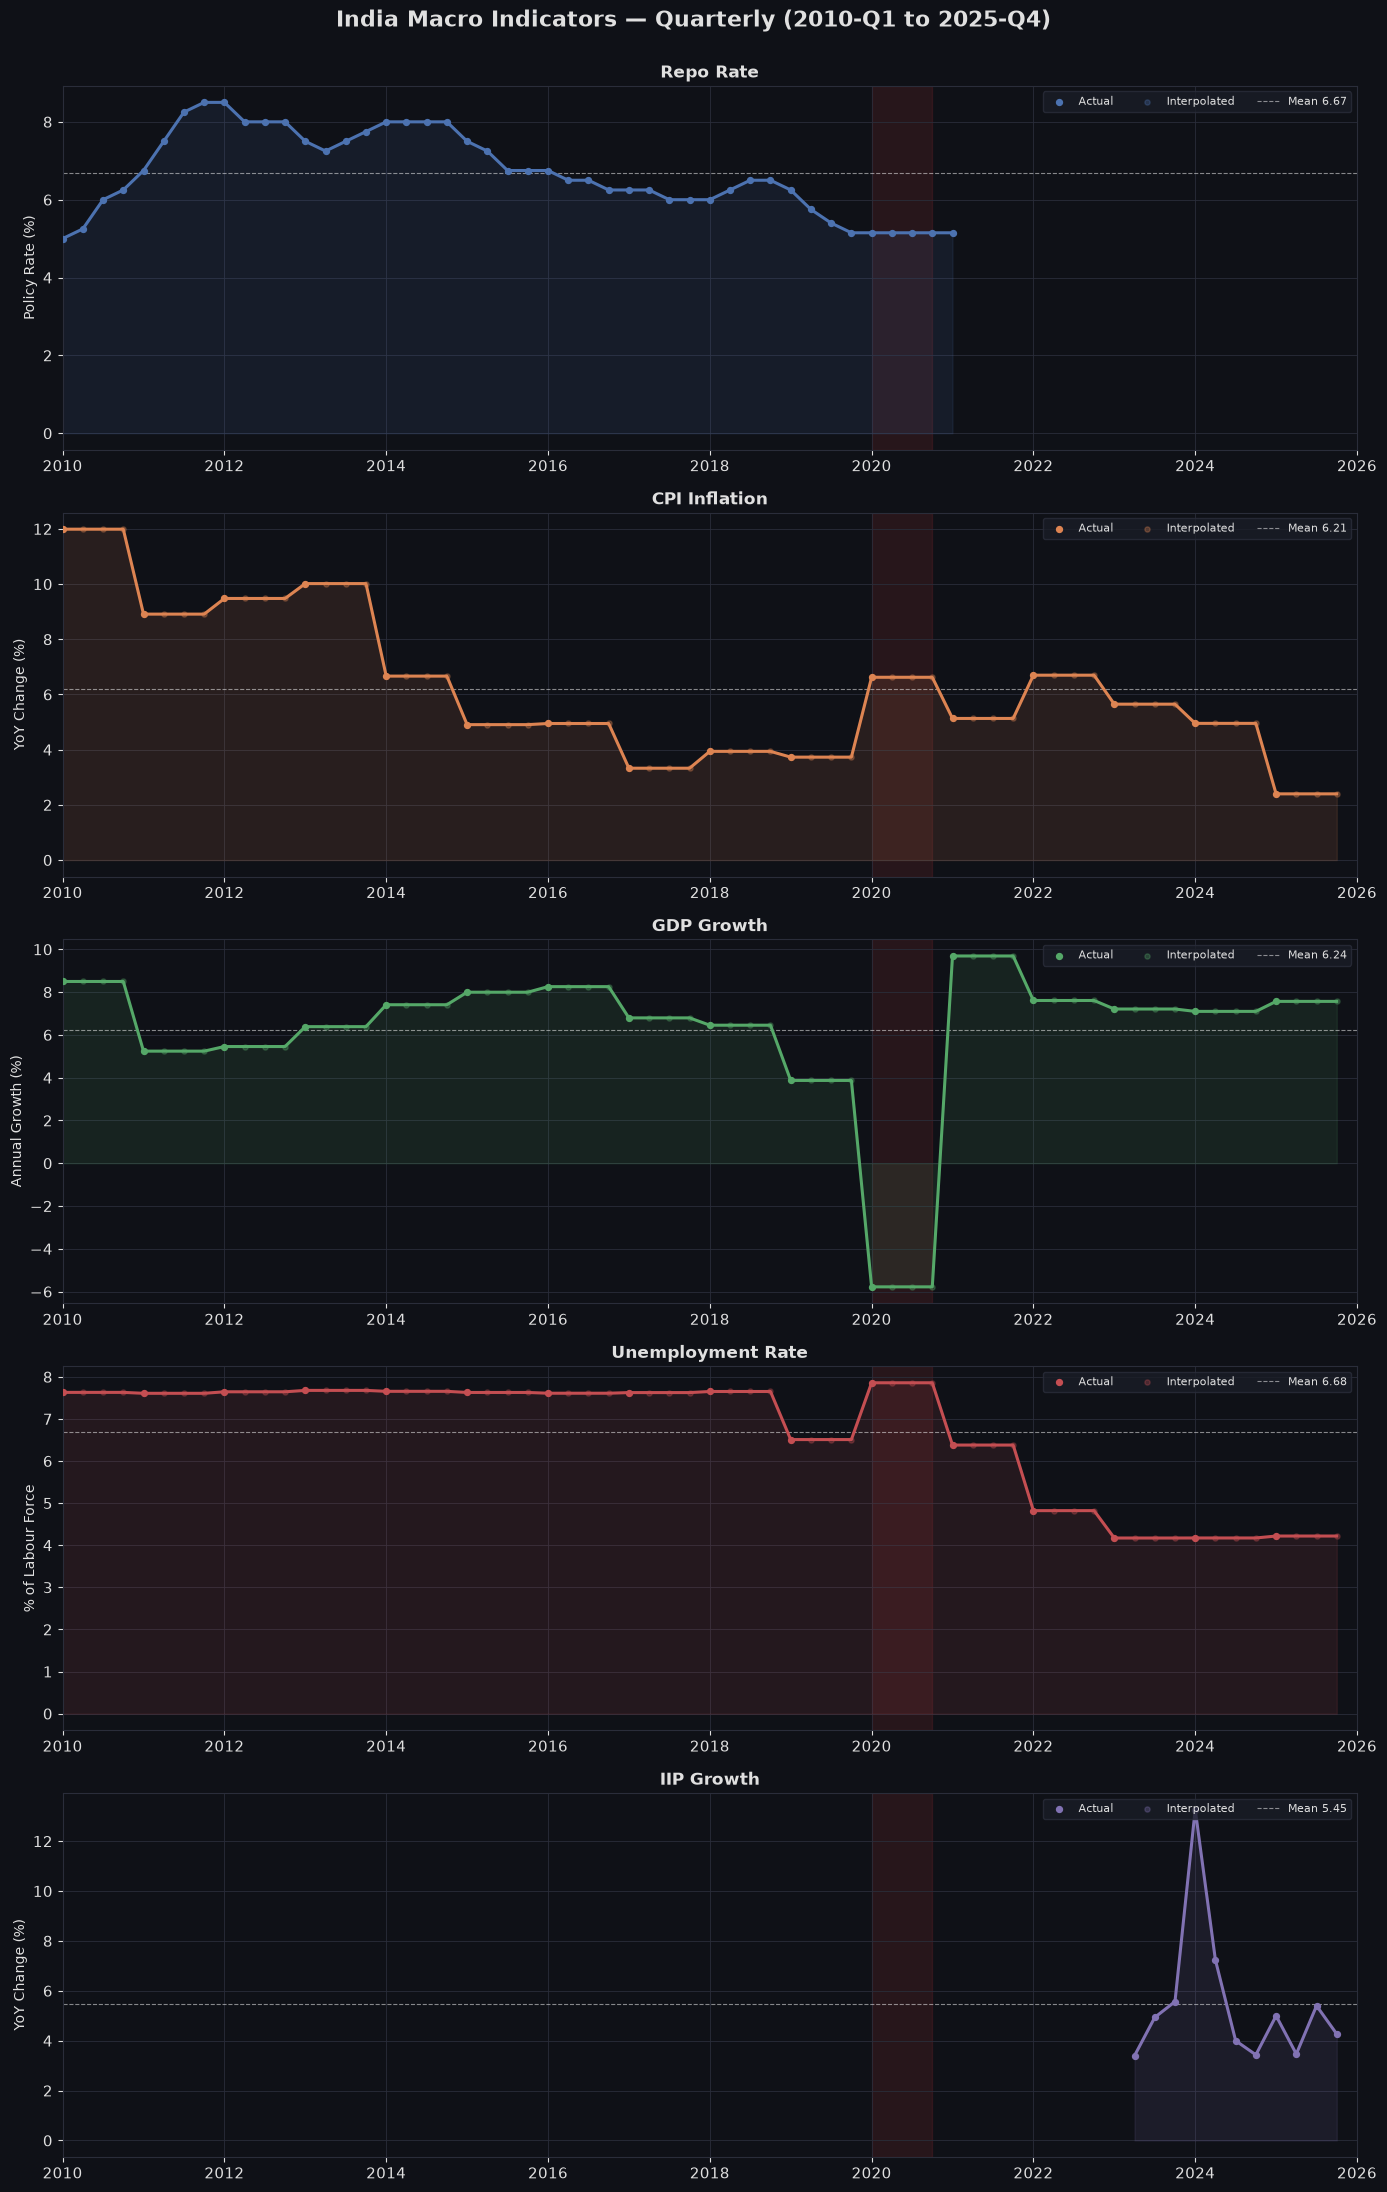

Saved -> docs/eda_timeseries.png


In [3]:
# -- Section 2: Time-series plots -----------------------------------------
RECESSION_BANDS = [(2020.0, 2020.75, 'COVID-19')]

fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=False)
fig.suptitle('India Macro Indicators — Quarterly (2010-Q1 to 2025-Q4)',
             fontsize=16, fontweight='bold', y=0.995, color=TEXT_COLOR)
fig.patch.set_facecolor(BG_COLOR)

for ax, col, color in zip(axes, VALUE_COLS, PALETTE):
    s = df[col].dropna()
    x = [quarter_to_float(q) for q in s.index]

    ax.plot(x, s.values, color=color, linewidth=2.2, zorder=3)
    ax.fill_between(x, s.values, alpha=0.12, color=color, zorder=2)

    flag_col = col + '_is_interpolated'
    if flag_col in df_raw.columns:
        flag  = df_raw.loc[s.index, flag_col]
        act_x = [quarter_to_float(q) for q in flag[flag == False].index]
        act_v = s[flag == False].values
        int_x = [quarter_to_float(q) for q in flag[flag == True].index]
        int_v = s[flag == True].values
        ax.scatter(act_x, act_v, s=18, color=color, zorder=5, label='Actual')
        ax.scatter(int_x, int_v, s=14, color=color, alpha=0.30,
                   marker='o', zorder=4, label='Interpolated')

    ax.axhline(s.mean(), color='white', lw=0.8, ls='--',
               alpha=0.5, label=f'Mean {s.mean():.2f}')
    for r_start, r_end, _ in RECESSION_BANDS:
        ax.axvspan(r_start, r_end, color='#FF4444', alpha=0.10, zorder=1)

    ax.set_ylabel(UNITS[col], fontsize=10)
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold', pad=6)
    ax.set_xlim(2010, 2026)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.legend(fontsize=8, loc='upper right', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.savefig('../docs/eda_timeseries.png', dpi=150,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Saved -> docs/eda_timeseries.png')

**Legend**: solid dots = actual observations; faded dots = quarters interpolated from annual value.  
Red band = COVID-19 contraction (2020). Dashed white = in-sample mean.  
`Repo_Rate` ends 2021-Q1 (data cutoff); `IIP_Growth` starts 2023-Q2.


---
## Section 3 — Correlation Heatmap

> **Note**: `IIP_Growth` and `Repo_Rate` have non-overlapping coverage windows,
> so listwise deletion leaves 0 complete rows. **Pairwise deletion** (`min_periods=8`)
> is used instead; `n/a` appears where fewer than 8 shared observations exist.


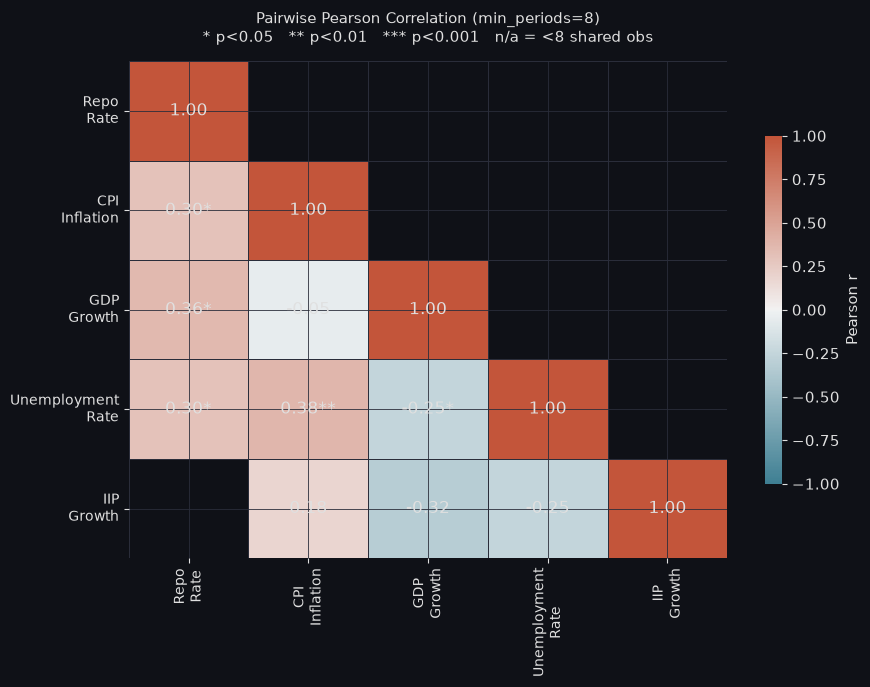

Saved -> docs/eda_correlation.png

Pairwise Pearson r:
                   Repo_Rate  CPI_Inflation  GDP_Growth  Unemployment_Rate  IIP_Growth
Repo_Rate              1.000          0.298       0.363              0.304         NaN
CPI_Inflation          0.298          1.000      -0.049              0.382       0.184
GDP_Growth             0.363         -0.049       1.000             -0.251      -0.323
Unemployment_Rate      0.304          0.382      -0.251              1.000      -0.251
IIP_Growth               NaN          0.184      -0.323             -0.251       1.000


In [4]:
# -- Section 3: Pairwise Pearson correlation heatmap -----------------------
# IIP_Growth and Repo_Rate have non-overlapping windows -> 0 complete rows.
# We use pairwise deletion (min_periods=8) so the heatmap is fully populated.
MIN_PERIODS = 8

corr_pw = df.corr(method='pearson', min_periods=MIN_PERIODS)

def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

pval_pw = pd.DataFrame(float('nan'), index=corr_pw.index, columns=corr_pw.columns)
for c1 in VALUE_COLS:
    for c2 in VALUE_COLS:
        if c1 != c2:
            pair = df[[c1, c2]].dropna()
            if len(pair) >= MIN_PERIODS:
                _, p = stats.pearsonr(pair[c1], pair[c2])
                pval_pw.loc[c1, c2] = p

annot = corr_pw.copy().astype(object)
for r in corr_pw.index:
    for c in corr_pw.columns:
        v = corr_pw.loc[r, c]
        p = pval_pw.loc[r, c]
        if pd.isna(v):    annot.loc[r, c] = 'n/a'
        elif r == c:      annot.loc[r, c] = f'{v:.2f}'
        else:
            suf = stars(p) if not pd.isna(p) else ''
            annot.loc[r, c] = f'{v:.2f}{suf}'

mask = np.triu(np.ones_like(corr_pw, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.heatmap(
    corr_pw, mask=mask, annot=annot, fmt='', cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor=GRID_COLOR,
    annot_kws={'size': 12, 'color': TEXT_COLOR},
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
    ax=ax,
)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT_COLOR)
cbar.ax.tick_params(colors=TEXT_COLOR)

short_names = [c.replace('_', '\n') for c in VALUE_COLS]
ax.set_xticklabels(short_names, fontsize=10, color=TEXT_COLOR)
ax.set_yticklabels(short_names, fontsize=10, color=TEXT_COLOR, rotation=0)
ax.set_title(
    f'Pairwise Pearson Correlation (min_periods={MIN_PERIODS})\n'
    '* p<0.05   ** p<0.01   *** p<0.001   n/a = <8 shared obs',
    fontsize=11, pad=14, color=TEXT_COLOR
)
plt.tight_layout()
plt.savefig('../docs/eda_correlation.png', dpi=150,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Saved -> docs/eda_correlation.png')
print()
print('Pairwise Pearson r:')
print(corr_pw.round(3).to_string())

---
## Section 4 — ADF Stationarity Tests

H0: unit root present (non-stationary). Reject H0 at p <= 0.05 → stationary.  
`regression='ct'` (constant + trend) for trending series; `'c'` (constant only) for others.  
Lag order selected by AIC (`autolag='AIC'`).


In [5]:
# -- Section 4: ADF stationarity tests ------------------------------------
REGRESSION = {
    'Repo_Rate':         'ct',
    'CPI_Inflation':     'ct',
    'GDP_Growth':        'c',
    'Unemployment_Rate': 'ct',
    'IIP_Growth':        'c',
}

def run_adf(series, regression='ct'):
    s = series.dropna()
    if len(s) < 10:
        return dict(n_obs=len(s), n_lags=None, ADF_Stat=None,
                    p_value=None, Crit_5pct=None, Stationary='N/A (n<10)')
    res = adfuller(s, autolag='AIC', regression=regression)
    adf_stat, p_value, n_lags, n_obs, crit = res[0], res[1], res[2], res[3], res[4]
    return dict(
        n_obs=n_obs, n_lags=n_lags,
        ADF_Stat=round(adf_stat, 4), p_value=round(p_value, 4),
        Crit_1pct=round(crit['1%'], 4), Crit_5pct=round(crit['5%'], 4),
        Crit_10pct=round(crit['10%'], 4),
        Stationary='YES' if p_value <= 0.05 else 'NO',
    )

adf_results = {col: run_adf(df[col], REGRESSION[col]) for col in VALUE_COLS}
adf_df = pd.DataFrame(adf_results).T

print('='*90)
print('  ADF TEST  (H0: unit root present = non-stationary, reject at p <= 0.05)')
print('='*90)
print(adf_df.to_string())
print()
for col in VALUE_COLS:
    r = adf_results[col]
    mark = 'OK' if r['Stationary'] == 'YES' else 'X '
    p_str = f"p={r['p_value']:.4f}" if r['p_value'] is not None else 'n/a'
    print(f'  [{mark}] {col:<25} {r["Stationary"]:<5}  ({p_str})')

non_stationary = [c for c in VALUE_COLS if adf_results[c]['Stationary'] == 'NO']
stationary     = [c for c in VALUE_COLS if adf_results[c]['Stationary'] == 'YES']
print(f'\n  Stationary   : {stationary}')
print(f'  Non-stationary: {non_stationary}')

  ADF TEST  (H0: unit root present = non-stationary, reject at p <= 0.05)
                  n_obs n_lags ADF_Stat p_value Crit_1pct Crit_5pct Crit_10pct Stationary
Repo_Rate            38      6  -2.8713   0.172   -4.2191   -3.5331    -3.1982         NO
CPI_Inflation        63      0  -2.1841  0.4988   -4.1102   -3.4826    -3.1692         NO
GDP_Growth           59      4  -2.3569  0.1543   -3.5464   -2.9119    -2.5937         NO
Unemployment_Rate    63      0   -1.923  0.6427   -4.1102   -3.4826    -3.1692         NO
IIP_Growth           10      0  -2.2933  0.1742   -4.3316    -3.233    -2.7487         NO

  [X ] Repo_Rate                 NO     (p=0.1720)
  [X ] CPI_Inflation             NO     (p=0.4988)
  [X ] GDP_Growth                NO     (p=0.1543)
  [X ] Unemployment_Rate         NO     (p=0.6427)
  [X ] IIP_Growth                NO     (p=0.1742)

  Stationary   : []
  Non-stationary: ['Repo_Rate', 'CPI_Inflation', 'GDP_Growth', 'Unemployment_Rate', 'IIP_Growth']


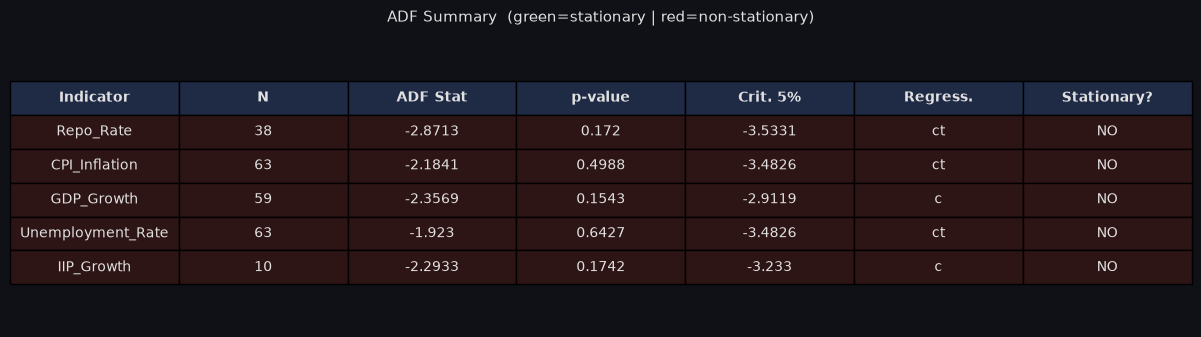

Saved -> docs/eda_adf_table.png


In [6]:
# -- ADF visual table -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 3.5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axis('off')

table_data = [
    [col, adf_df.loc[col,'n_obs'], adf_df.loc[col,'ADF_Stat'],
     adf_df.loc[col,'p_value'],   adf_df.loc[col,'Crit_5pct'],
     REGRESSION[col],             adf_df.loc[col,'Stationary']]
    for col in VALUE_COLS
]
headers = ['Indicator','N','ADF Stat','p-value','Crit. 5%','Regress.','Stationary?']

tbl = ax.table(cellText=table_data, colLabels=headers,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.9)
for j in range(len(headers)):
    tbl[(0,j)].set_facecolor('#1F2A44')
    tbl[(0,j)].set_text_props(color=TEXT_COLOR, fontweight='bold')
for i, col in enumerate(VALUE_COLS, 1):
    ok = adf_results[col]['Stationary'] == 'YES'
    rc = '#152E1F' if ok else '#2E1515'
    for j in range(len(headers)):
        tbl[(i,j)].set_facecolor(rc)
        tbl[(i,j)].set_text_props(color=TEXT_COLOR)
ax.set_title('ADF Summary  (green=stationary | red=non-stationary)',
             fontsize=11, color=TEXT_COLOR, pad=12)
plt.tight_layout()
plt.savefig('../docs/eda_adf_table.png', dpi=150,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Saved -> docs/eda_adf_table.png')

---
## Section 5 — First-Order Differencing

For each non-stationary series: `delta_y_t = y_t - y_{t-1}`.  
A series stationary only after differencing is **I(1)** (integrated of order 1).

**Why this matters**:
- VAR/VECM models require all inputs to be stationary or cointegrated
- Granger causality tests must operate on stationary series
- OLS on non-stationary series → spurious regression


ADF on first-differenced series:

                    n_obs n_lags ADF_Stat p_value Crit_1pct Crit_5pct Crit_10pct Stationary
d_Repo_Rate            38      5   -5.178     0.0   -3.6155   -2.9413    -2.6092        YES
d_CPI_Inflation        62      0  -7.9937     0.0   -3.5405   -2.9094    -2.5923        YES
d_GDP_Growth           59      3  -5.9097     0.0   -3.5464   -2.9119    -2.5937        YES
d_Unemployment_Rate    62      0  -7.9304     0.0   -3.5405   -2.9094    -2.5923        YES
d_IIP_Growth            9      0  -3.3718   0.012   -4.4731   -3.2899    -2.7724        YES

Integration order summary:
  I(1)   Repo_Rate                 stationary after first diff
  I(1)   CPI_Inflation             stationary after first diff
  I(1)   GDP_Growth                stationary after first diff
  I(1)   Unemployment_Rate         stationary after first diff
  I(1)   IIP_Growth                stationary after first diff


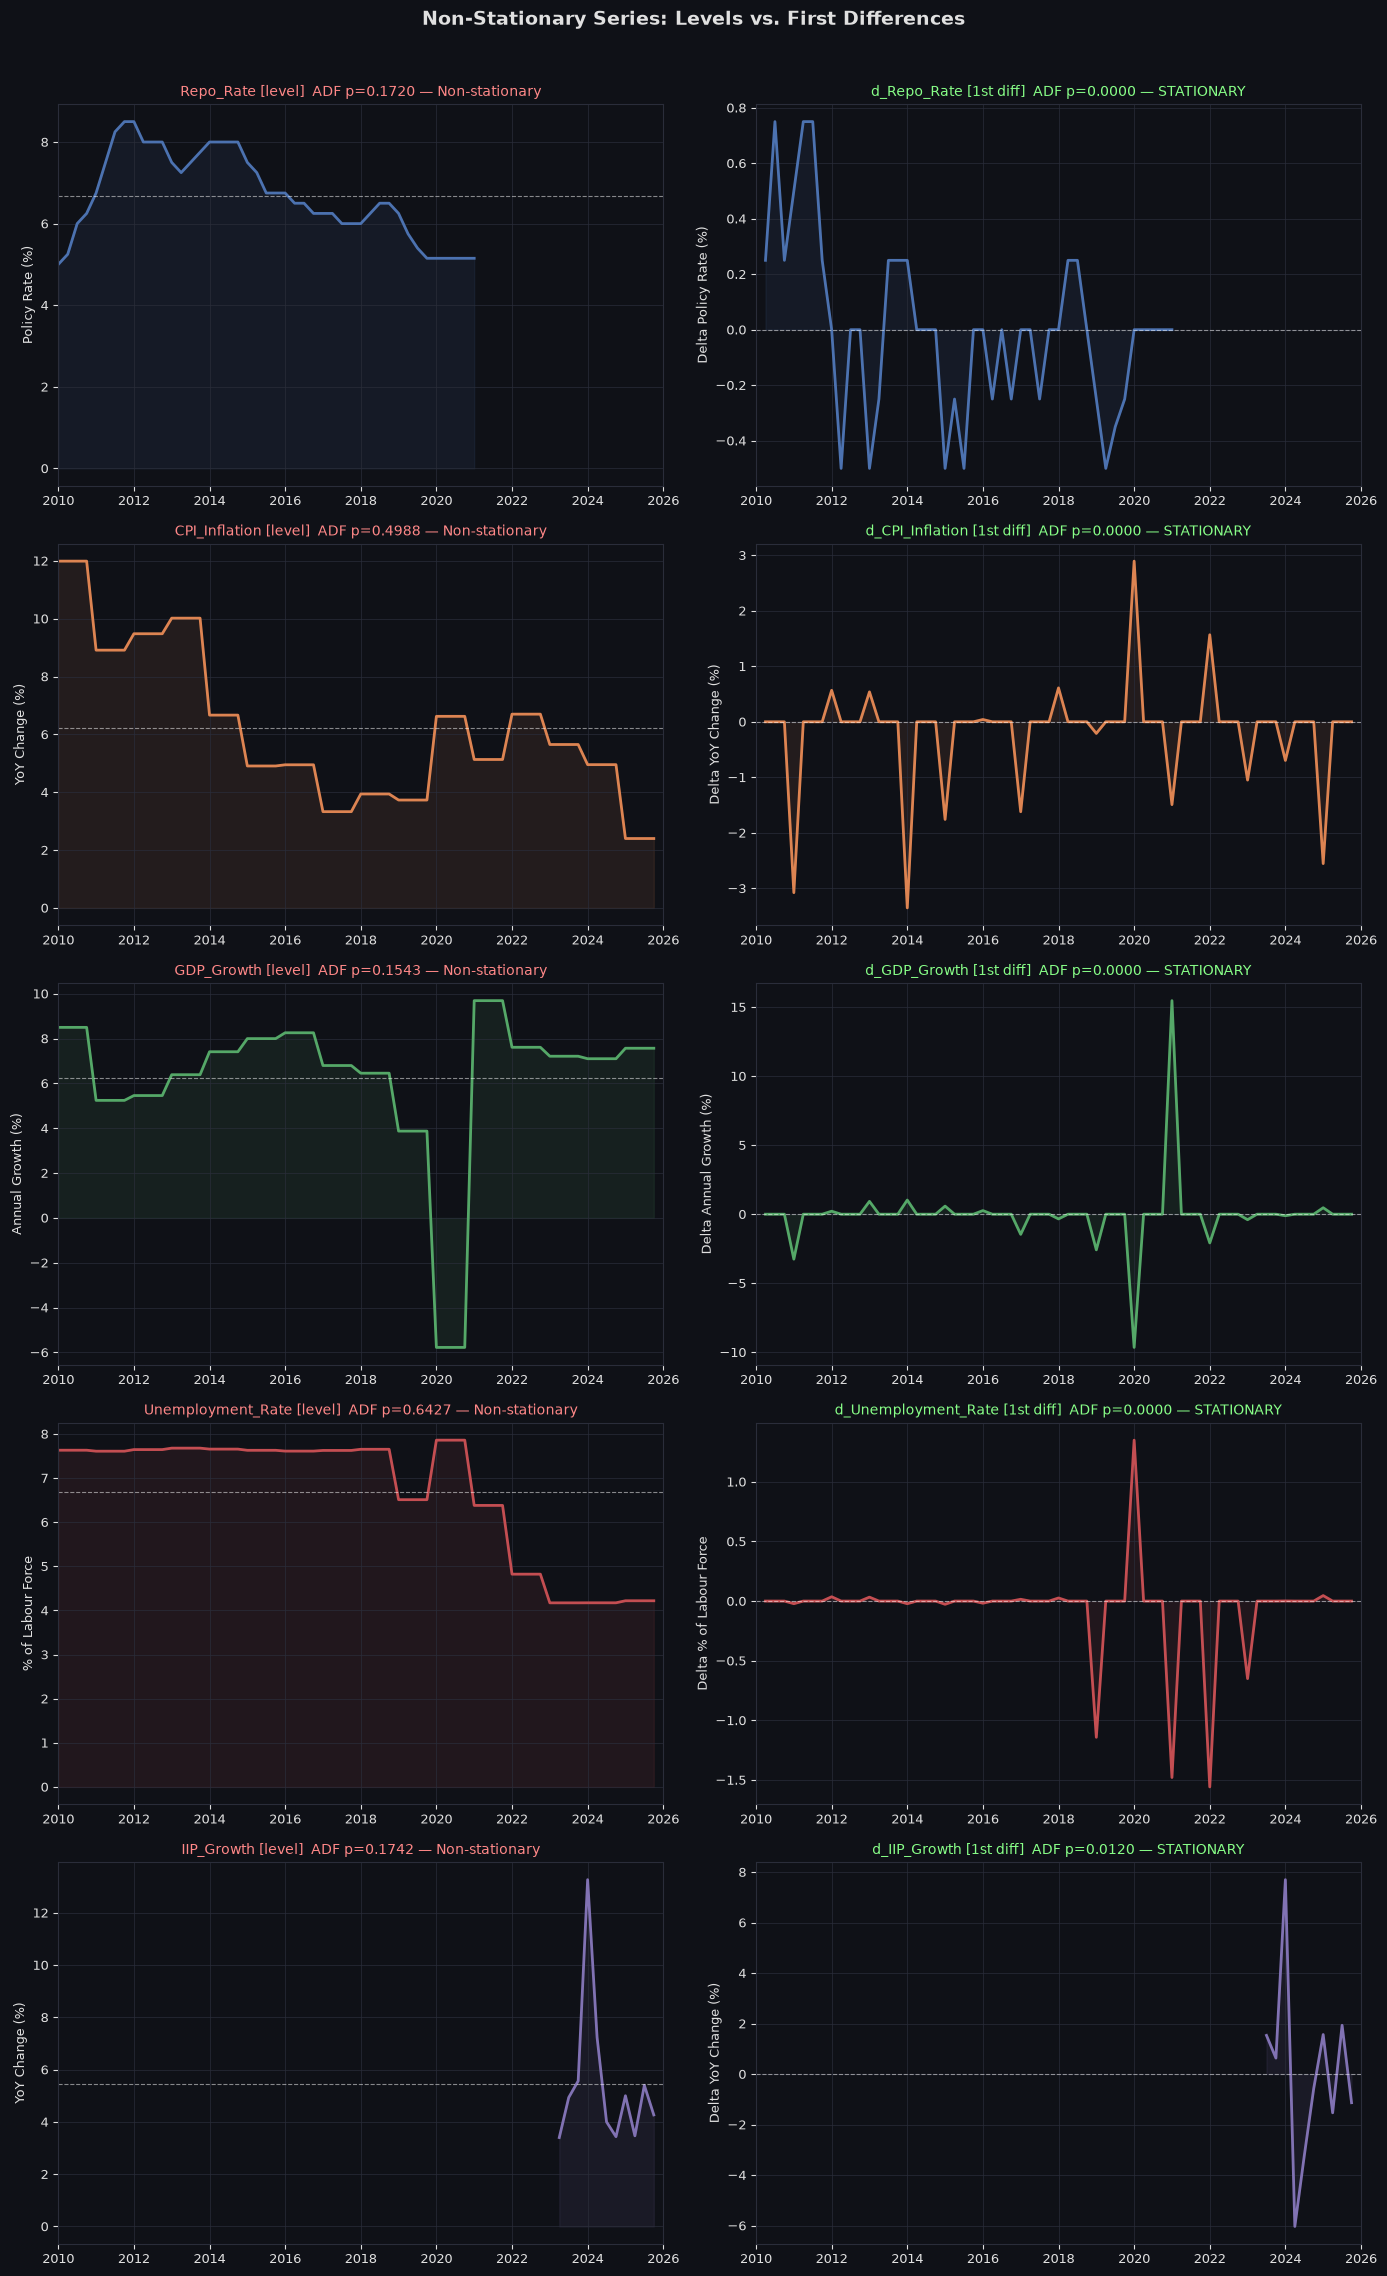

Saved -> docs/eda_differencing.png

Model-ready shape: (64, 5)  cols: ['d_Repo_Rate', 'd_CPI_Inflation', 'd_GDP_Growth', 'd_Unemployment_Rate', 'd_IIP_Growth']
Empty DataFrame
Columns: [d_Repo_Rate, d_CPI_Inflation, d_GDP_Growth, d_Unemployment_Rate, d_IIP_Growth]
Index: []


In [7]:
# -- Section 5: First-order differencing + ADF re-test --------------------
if not non_stationary:
    print('All series stationary at level — no differencing needed.')
else:
    df_diff      = pd.DataFrame(index=df.index)
    diff_results = {}
    for col in non_stationary:
        d_col = f'd_{col}'
        df_diff[d_col] = df[col].diff()
        diff_results[d_col] = run_adf(df_diff[d_col], regression='c')

    diff_adf_df = pd.DataFrame(diff_results).T
    print('ADF on first-differenced series:\n')
    print(diff_adf_df.to_string())
    print('\nIntegration order summary:')
    for col in VALUE_COLS:
        d_col = f'd_{col}'
        r0 = adf_results[col]
        if r0['Stationary'] == 'YES':
            print(f'  I(0)   {col:<25} stationary at level')
        elif d_col in diff_results:
            if diff_results[d_col]['Stationary'] == 'YES':
                print(f'  I(1)   {col:<25} stationary after first diff')
            else:
                print(f'  I(2+?) {col:<25} still non-stationary — check manually')
        else:
            print(f'  N/A    {col:<25} insufficient data')

    # Plot levels vs. diffs
    n_ns = len(non_stationary)
    fig, axes = plt.subplots(n_ns, 2, figsize=(14, 4.5*n_ns), squeeze=False)
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle('Non-Stationary Series: Levels vs. First Differences',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, y=1.01)

    for row_i, (col, color) in enumerate(zip(non_stationary, PALETTE)):
        ax_lev, ax_dif = axes[row_i]
        s  = df[col].dropna()
        xl = [quarter_to_float(q) for q in s.index]
        d_col = f'd_{col}'
        sd = df_diff[d_col].dropna()
        xd = [quarter_to_float(q) for q in sd.index]

        p_orig = adf_results[col]['p_value']
        p_diff = diff_results.get(d_col, {}).get('p_value')

        ax_lev.set_facecolor(BG_COLOR)
        ax_lev.plot(xl, s.values, color=color, linewidth=2)
        ax_lev.fill_between(xl, s.values, alpha=0.10, color=color)
        ax_lev.axhline(s.mean(), color='white', lw=0.8, ls='--', alpha=0.5)
        ax_lev.set_title(f'{col} [level]  ADF p={p_orig:.4f} — Non-stationary',
                         fontsize=10, color='#FF8888')
        ax_lev.set_ylabel(UNITS[col], fontsize=9)
        ax_lev.set_xlim(2010, 2026)

        if p_diff is not None:
            st_str   = 'STATIONARY' if p_diff <= 0.05 else 'still non-stationary'
            st_color = '#88FF88'    if p_diff <= 0.05 else '#FF8888'
            td = f'd_{col} [1st diff]  ADF p={p_diff:.4f} — {st_str}'
        else:
            st_color, td = '#AAAAAA', f'd_{col} — insufficient data'

        ax_dif.set_facecolor(BG_COLOR)
        ax_dif.plot(xd, sd.values, color=color, linewidth=2)
        ax_dif.fill_between(xd, sd.values, alpha=0.10, color=color)
        ax_dif.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
        ax_dif.set_title(td, fontsize=10, color=st_color)
        ax_dif.set_ylabel(f'Delta {UNITS[col]}', fontsize=9)
        ax_dif.set_xlim(2010, 2026)

        for ax in [ax_lev, ax_dif]:
            ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
            ax.tick_params(labelsize=9)
            ax.grid(True, color=GRID_COLOR, linewidth=0.5)

    plt.tight_layout()
    plt.savefig('../docs/eda_differencing.png', dpi=150,
                bbox_inches='tight', facecolor=BG_COLOR)
    plt.show()
    print('Saved -> docs/eda_differencing.png')

    # Model-ready DataFrame
    df_model = pd.DataFrame(index=df.index)
    for col in VALUE_COLS:
        d_col = f'd_{col}'
        if col in stationary:
            df_model[col] = df[col]
        elif d_col in diff_results and diff_results[d_col]['Stationary'] == 'YES':
            df_model[d_col] = df_diff[d_col]
        else:
            df_model[col] = df[col]
    print(f'\nModel-ready shape: {df_model.shape}  cols: {df_model.columns.tolist()}')
    print(df_model.dropna().tail(6).round(4).to_string())

### Modelling implications

| Series | Order | Action |
|---|---|---|
| All five series | I(1) per ADF | Use first differences for VAR/Granger; test for cointegration before VECM |
| IIP_Growth | I(1) — but n=11 | ADF unreliable at n<20; gather more data before relying on this result |

**Next step**: run Johansen cointegration test on the I(1) subset to determine if a VECM is more appropriate than a differenced VAR.
